### 2023-2025 통합 데이터 불러오기
- 약 4분 소요

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

merged_df = pd.read_csv('../data/processed_merged_df.csv', low_memory=False)
merged_df['측정시간'] = pd.to_datetime(merged_df['측정시간'], errors='coerce')

meta_cols = ['모델번호', '시리얼', '측정시간', '지역', '자치구', '행정동', '등록일자', '등록일시',
             '__source_file', '측정시간_raw', '시리얼_matched', '주소', '위도', '경도']
measure_cols = [c for c in merged_df.columns if c not in meta_cols]
print(f"측정값 컬럼 수: {len(measure_cols)}개")

측정값 컬럼 수: 52개


### 15개 카테고리 정의

In [ ]:
feature_groups = {
    '온도': ['온도 최대(℃)', '온도 평균(℃)', '온도 최소(℃)'],
    '습도': ['습도 최대(%)', '습도 평균(%)', '습도 최소(%)'],
    '풍속': ['풍속 최대(m/s)', '풍속 평균(m/s)', '풍속 최소(m/s)'],
    '풍향': ['풍향 최대(m/s)', '풍향 평균(m/s)', '풍향 최소(m/s)'],
    '조도': ['조도 최대(lux)', '조도 평균(lux)', '조도 최소(lux)'],
    '자외선': ['자외선 최대(UV)', '자외선 평균(UV)', '자외선 최소(UV)'],
    '소음': ['소음 최대(dB)', '소음 평균(dB)', '소음 최소(dB)'],
    '진동': ['진동(x) 최대(mm/s)', '진동(x) 평균(mm/s)', '진동(x) 최소(mm/s)',
             '진동(y) 최대(mm/s)', '진동(y) 평균(mm/s)', '진동(y) 최소(mm/s)',
             '진동(z) 최대(mm/s)', '진동(z) 평균(mm/s)', '진동(z) 최소(mm/s)'],
    '흑구온도': ['흑구온도 최대(℃)', '흑구온도 평균(℃)', '흑구온도 최소(℃)'],
    '이산화질소': ['이산화질소 최대(ppm)', '이산화질소 평균(ppm)', '이산화질소 최소(ppm)'],
    '일산화탄소': ['일산화탄소 최대(ppm)', '일산화탄소 평균(ppm)', '일산화탄소 최소(ppm)'],
    '이산화황': ['이산화황 최대(ppm)', '이산화황 평균(ppm)', '이산화황 최소(ppm)'],
    '암모니아': ['암모니아 평균(ppm)', '암모니아 최소(ppm)'],
    '황화수소': ['황화수소 최대(ppm)', '황화수소 평균(ppm)', '황화수소 최소(ppm)'],
    '오존': ['오존 최대(ppm)', '오존 평균(ppm)', '오존 최소(ppm)'],
}

# 실제 존재하는 컬럼만 필터 (오타/공백 대비)
for k, v in feature_groups.items():
    feature_groups[k] = [c for c in v if c in merged_df.columns]

print(f"카테고리 수: {len(feature_groups)}개")  

카테고리 수: 15개


In [8]:
feature_summary = []
for group, cols in feature_groups.items():
    avg_col = [c for c in cols if '평균' in c]
    if not avg_col:
        continue
    col = avg_col[0]
    feature_summary.append({
        '카테고리': group,
        '결측률': merged_df[col].isna().mean(),
        '관측치수': merged_df[col].notna().sum(),
        '최초기록': merged_df.loc[merged_df[col].notna(), '측정시간'].min(),
    })

feature_summary_df = pd.DataFrame(feature_summary)
print(feature_summary_df)

     카테고리       결측률     관측치수                최초기록
0      온도  0.076973  4116010 2023-06-05 01:07:00
1      습도  0.140282  3833698 2023-06-05 01:07:00
2      풍속  0.950105   222493 2023-06-05 01:07:00
3      풍향  0.950105   222493 2023-06-05 01:07:00
4      조도  0.204671  3546574 2023-06-05 01:07:00
5     자외선  0.198665  3573356 2023-06-05 01:07:00
6      소음  0.032071  4316239 2023-06-05 01:07:00
7      진동  0.223248  3463735 2023-06-05 01:07:00
8    흑구온도  0.995165    21562 2025-09-01 01:07:00
9   이산화질소  0.939637   269174 2023-06-05 01:07:00
10  일산화탄소  0.939638   269168 2023-06-05 01:07:00
11   이산화황  0.945821   241600 2023-06-05 01:07:00
12   암모니아  0.958241   186212 2023-06-05 01:07:00
13   황화수소  0.958464   185219 2023-06-05 01:07:00
14     오존  0.977479   100425 2023-06-05 01:07:00


# 일부 센서가 측정하는 항목 파악

In [14]:
merge_key = '시리얼_matched'  
print(merge_key, merge_key in merged_df.columns)

시리얼_matched True


In [22]:
# 센서별로 각 카테고리를 측정하는지 여부 (평균 컬럼 기준)
sensor_category_map = pd.DataFrame(index=merged_df[merge_key].unique())

for group, cols in feature_groups.items():
    avg_col = [c for c in cols if '평균' in c]
    if not avg_col:
        continue
    col = avg_col[0]
    availability = merged_df.groupby(merge_key)[col].apply(lambda x: x.notna().any())
    sensor_category_map[group] = availability

# 카테고리별로 몇 개 센서가 측정하는지 
category_sensor_counts = sensor_category_map.sum(axis=0).sort_values(ascending=False)
print(category_sensor_counts)
sensor_category_map.to_csv('../outputs/sensor_category_map.csv', encoding='utf-8-sig')

습도       1149
온도       1138
소음       1133
오존       1001
조도        927
자외선       925
진동        923
이산화질소      81
일산화탄소      80
이산화황       76
풍속         64
풍향         64
암모니아       50
황화수소       50
흑구온도       36
dtype: int64


# 측정패턴 그룹화 heatmap

폰트 설정

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Windows라면 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

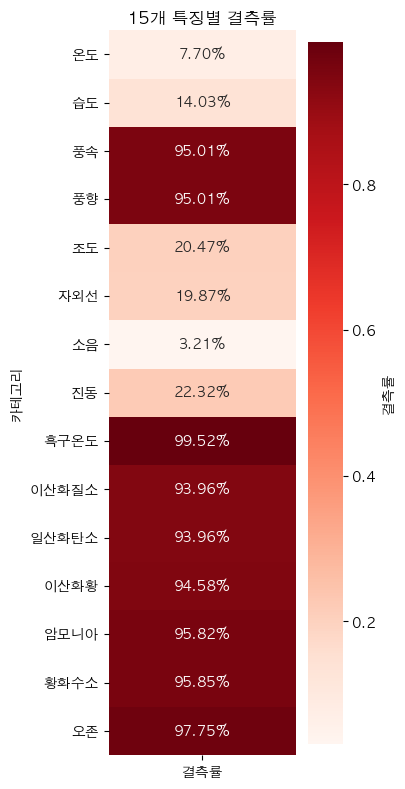

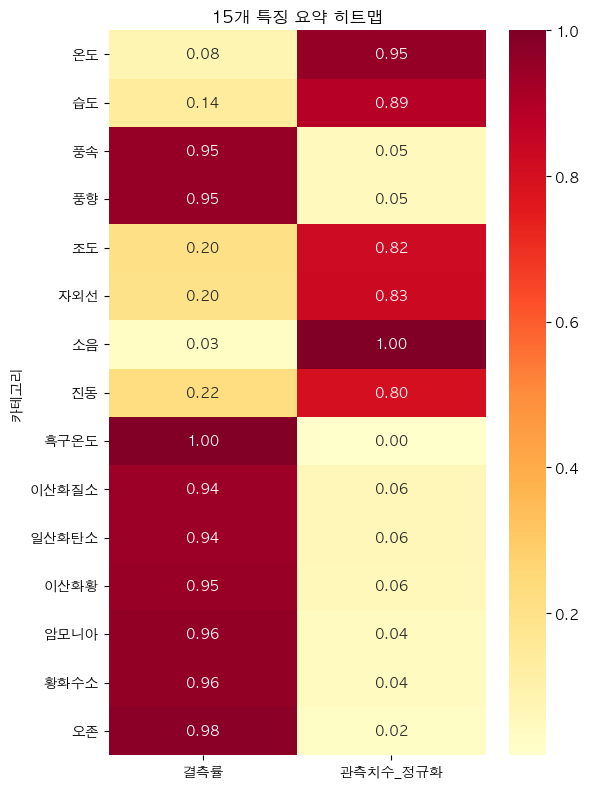

In [18]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 카테고리별 결측률 히트맵 (1열짜리 히트맵)
heatmap_data = feature_summary_df.set_index('카테고리')[['결측률']]

plt.figure(figsize=(4, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2%', cmap='Reds', cbar_kws={'label': '결측률'})
plt.title('15개 특징별 결측률')
plt.tight_layout()
plt.savefig('../outputs/15features_missing_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

heatmap_data2 = feature_summary_df.set_index('카테고리')[['결측률']].copy()
heatmap_data2['관측치수_정규화'] = feature_summary_df.set_index('카테고리')['관측치수'] / feature_summary_df['관측치수'].max()

plt.figure(figsize=(6, 8))
sns.heatmap(heatmap_data2, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('15개 특징 요약 히트맵')
plt.tight_layout()
plt.savefig('../outputs/15features_summary_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

# 특정 feature가 기록된 시점 파악
- 온도 / 이산화질소 / 오존

In [23]:
for group in ['온도', '이산화질소', '오존', '소음', '습도', '풍속', '풍향', '조도', '자외선', '진동', '흑구온도', '일산화탄소', '이산화황', '암모니아', '황화수소']:  
    col = [c for c in feature_groups[group] if '평균' in c][0]
    recorded = merged_df.loc[merged_df[col].notna(), '측정시간']
    print(f"{group}: {recorded.min()} ~ {recorded.max()} ({recorded.dt.date.nunique()}일)")

온도: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
이산화질소: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
오존: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
소음: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
습도: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
풍속: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
풍향: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
조도: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
자외선: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
진동: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
흑구온도: 2025-09-01 01:07:00 ~ 2025-09-30 23:07:00 (30일)
일산화탄소: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
이산화황: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
암모니아: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)
황화수소: 2023-06-05 01:07:00 ~ 2025-09-30 23:07:00 (209일)


# 전체 구간 대비 결측 파악

     카테고리       결측률
8    흑구온도  0.995165
14     오존  0.977479
13   황화수소  0.958464
12   암모니아  0.958241
2      풍속  0.950105
3      풍향  0.950105
11   이산화황  0.945821
10  일산화탄소  0.939638
9   이산화질소  0.939637
7      진동  0.223248
4      조도  0.204671
5     자외선  0.198665
1      습도  0.140282
0      온도  0.076973
6      소음  0.032071


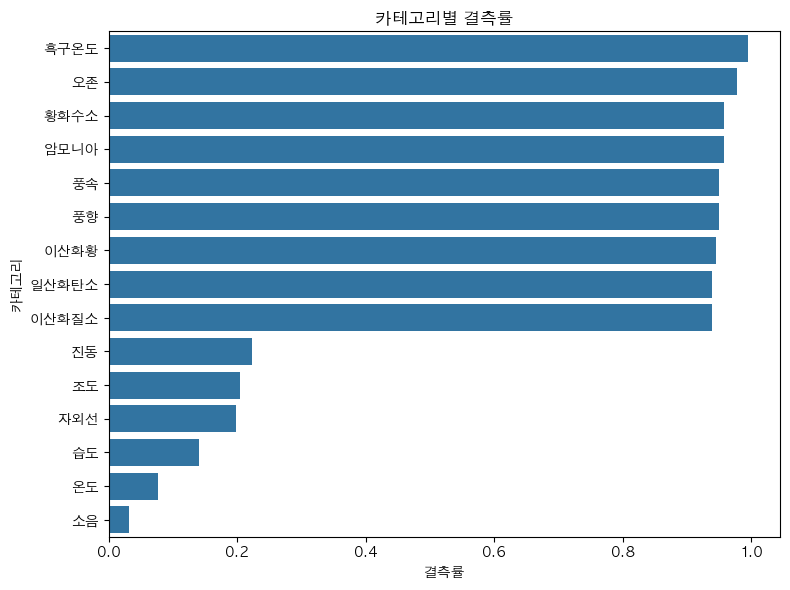

In [19]:
print(feature_summary_df[['카테고리', '결측률']].sort_values('결측률', ascending=False))

plt.figure(figsize=(8,6))
sns.barplot(data=feature_summary_df.sort_values('결측률', ascending=False), x='결측률', y='카테고리')
plt.title('카테고리별 결측률')
plt.tight_layout()
plt.savefig('../outputs/missing_ratio_barplot.png', dpi=100)
plt.show()

# 일별 주기성 확인
- 온도

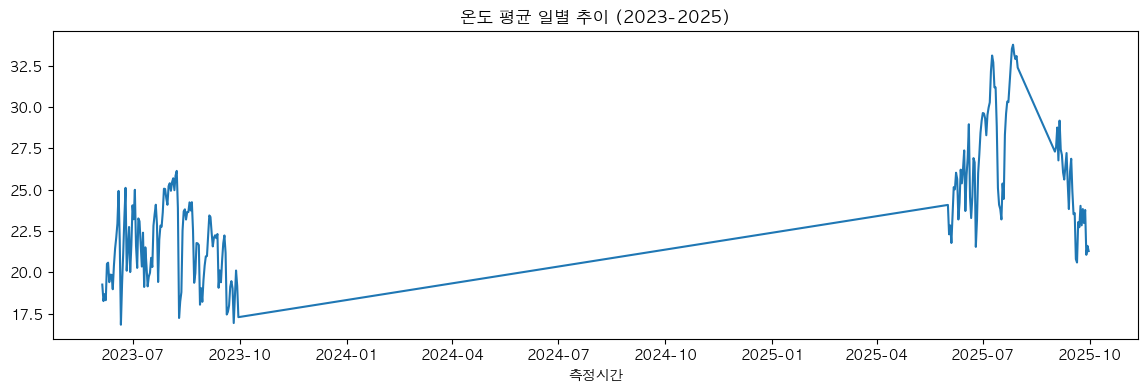

In [20]:
temp_col = '온도 평균(℃)'
daily_avg = merged_df.groupby(merged_df['측정시간'].dt.date)[temp_col].mean()

plt.figure(figsize=(14,4))
daily_avg.plot()
plt.title('온도 평균 일별 추이 (2023-2025)')
plt.savefig('../outputs/daily_temp_trend.png', dpi=100)
plt.show()